# 🔧 AI4I 2020 Predictive Maintenance
### End-to-End ML Pipeline: EDA → Feature Engineering → Model Training → FastAPI Export
**Models:** Random Forest | XGBoost  
**Dataset:** AI4I 2020 Predictive Maintenance Dataset (UCI)

## 📦 Step 1: Install & Import Libraries

In [1]:
# # Install required libraries (run once)
# ! pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib imbalanced-learn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 2: Load Dataset

In [3]:
# Load the dataset — update path if needed
df = pd.read_csv(r'D:\Predictive_Maintenance\data\ai4i2020.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (10000, 14)
Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
# Statistical summary
df.describe().round(2)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.0,310.01,1538.78,39.99,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2886.90,2.0,1.48,179.28,9.97,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,1.00,295.3,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2500.75,298.3,308.80,1423.00,33.20,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5000.50,300.1,310.10,1503.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7500.25,301.5,311.10,1612.00,46.80,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,10000.00,304.5,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [6]:
# ── 3.1 Missing values & duplicates ──────────────────────
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Duplicate rows: 0


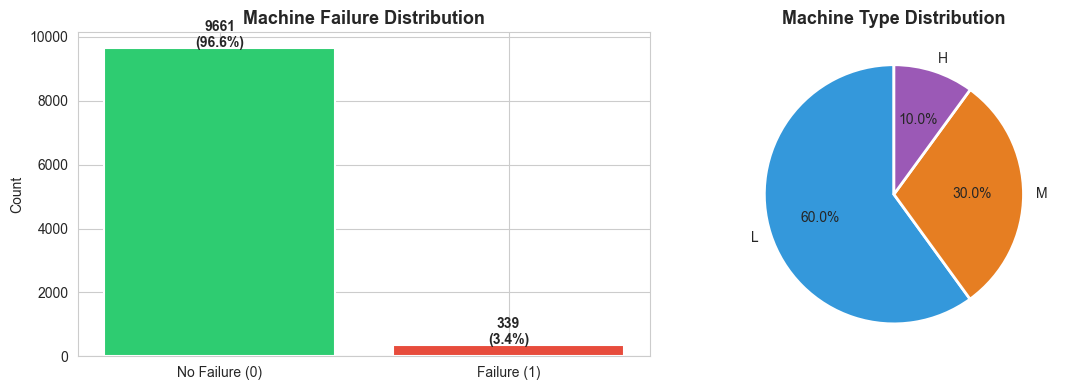


Class imbalance ratio: 1:28 (No Failure : Failure)


In [7]:
# ── 3.2 Target class distribution ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Machine failure count
failure_counts = df['Machine failure'].value_counts()
axes[0].bar(['No Failure (0)', 'Failure (1)'], failure_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Machine Failure Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(failure_counts.values):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Machine type distribution
type_counts = df['Type'].value_counts()
axes[1].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%', colors=['#3498db', '#e67e22', '#9b59b6'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Machine Type Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'\nClass imbalance ratio: 1:{int(failure_counts[0]/failure_counts[1])} (No Failure : Failure)')

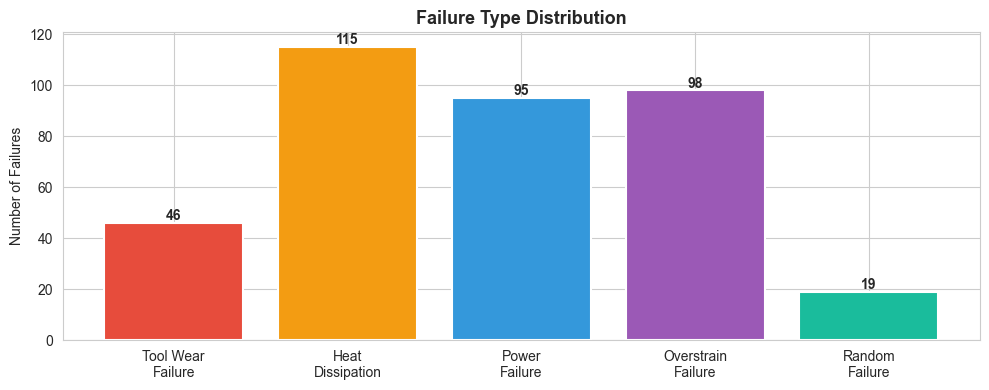

In [8]:
# ── 3.3 Failure type breakdown ────────────────────────────
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_labels = [
    'Tool Wear\nFailure', 'Heat\nDissipation', 'Power\nFailure',
    'Overstrain\nFailure', 'Random\nFailure'
]

fig, ax = plt.subplots(figsize=(10, 4))
counts = [df[c].sum() for c in failure_cols]
bars = ax.bar(failure_labels, counts,
              color=['#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#1abc9c'],
              edgecolor='white', linewidth=1.5)
ax.set_title('Failure Type Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Failures')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

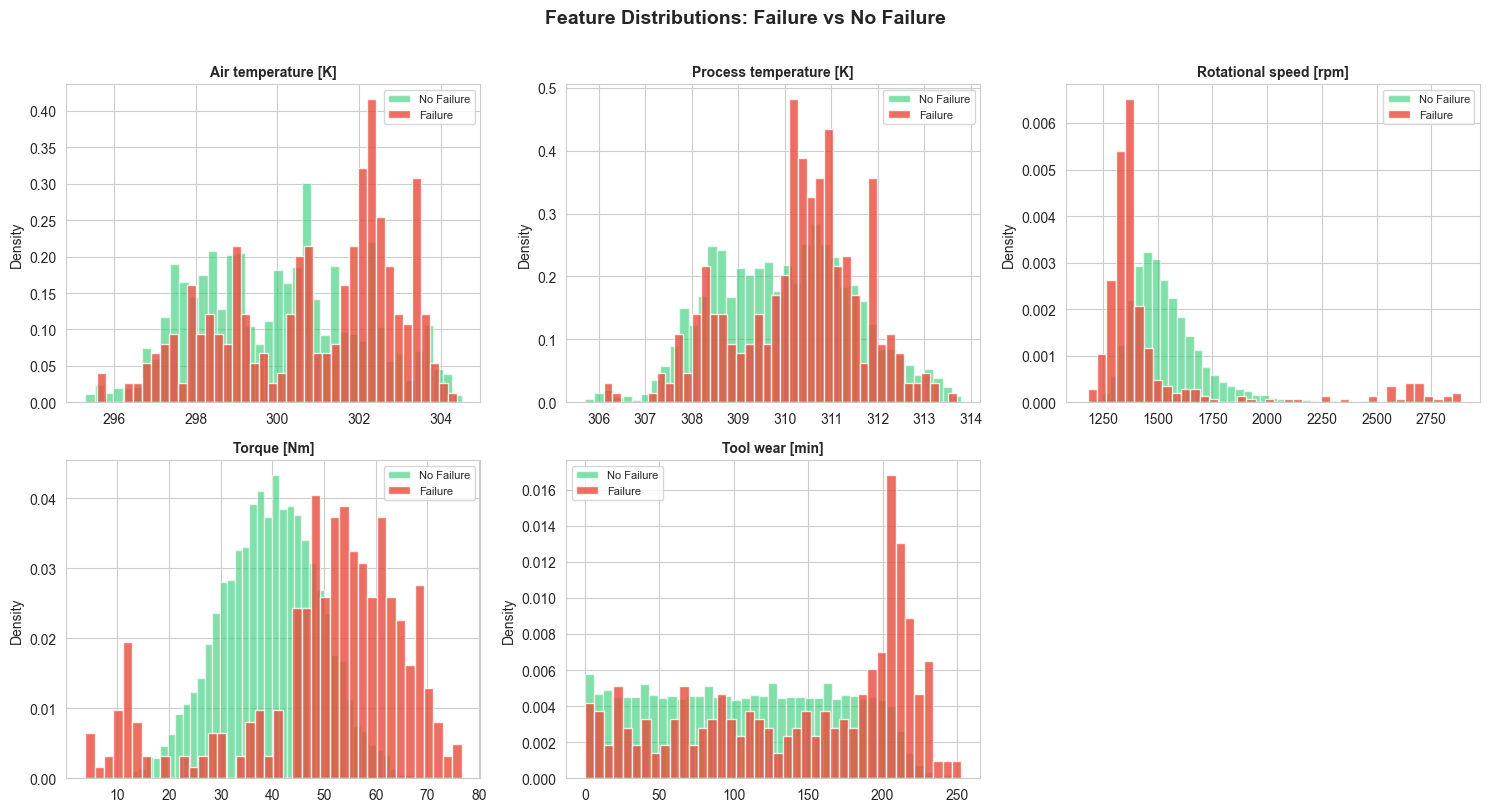

In [9]:
# ── 3.4 Feature distributions by failure label ────────────
numeric_cols = [
    'Air temperature [K]', 'Process temperature [K]',
    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, color, alpha in [(0, '#2ecc71', 0.6), (1, '#e74c3c', 0.8)]:
        axes[i].hist(
            df[df['Machine failure'] == label][col],
            bins=40, color=color, alpha=alpha,
            label='Failure' if label else 'No Failure', density=True
        )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

axes[5].axis('off')  # hide empty subplot
fig.suptitle('Feature Distributions: Failure vs No Failure', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

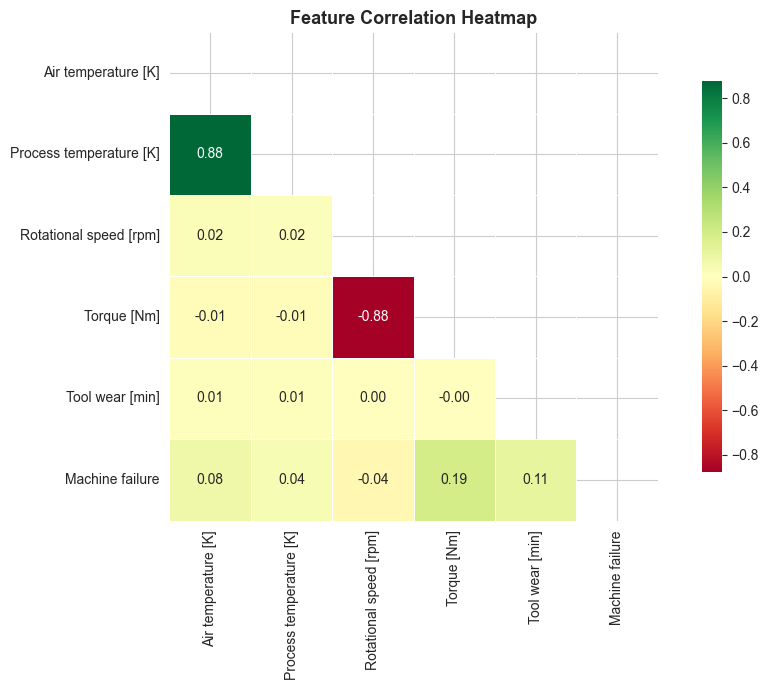

In [10]:
# ── 3.5 Correlation heatmap ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
corr_cols = numeric_cols + ['Machine failure']
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Failure rate by machine type:
      sum  count  failure_rate
Type                          
H      21   1003          2.09
L     235   6000          3.92
M      83   2997          2.77


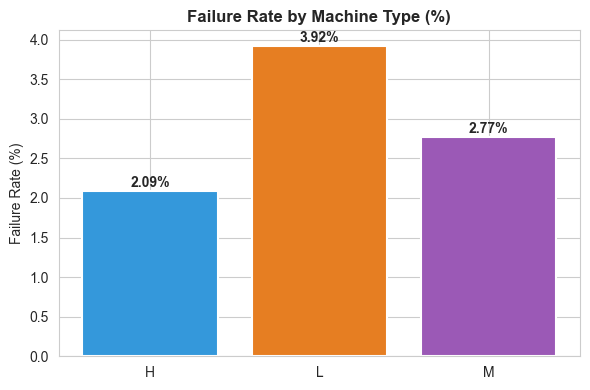

In [11]:
# ── 3.6 Failure rate by machine type ─────────────────────
failure_by_type = df.groupby('Type')['Machine failure'].agg(['sum', 'count'])
failure_by_type['failure_rate'] = (failure_by_type['sum'] / failure_by_type['count'] * 100).round(2)
print('Failure rate by machine type:')
print(failure_by_type)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(failure_by_type.index, failure_by_type['failure_rate'],
       color=['#3498db', '#e67e22', '#9b59b6'], edgecolor='white', linewidth=1.5)
ax.set_title('Failure Rate by Machine Type (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Failure Rate (%)')
for i, (idx, row) in enumerate(failure_by_type.iterrows()):
    ax.text(i, row['failure_rate'] + 0.05, f"{row['failure_rate']}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## ⚙️ Step 4: Feature Engineering

In [12]:
df_eng = df.copy()

# ── 4.1 Temperature delta ─────────────────────────────────
df_eng['temp_delta'] = df_eng['Process temperature [K]'] - df_eng['Air temperature [K]']

# ── 4.2 Power = Torque × Angular velocity ─────────────────
# ω (rad/s) = RPM × 2π / 60
df_eng['power_watts'] = df_eng['Torque [Nm]'] * (df_eng['Rotational speed [rpm]'] * 2 * np.pi / 60)

# ── 4.3 Tool wear rate (torque × wear) ────────────────────
df_eng['wear_torque_interaction'] = df_eng['Tool wear [min]'] * df_eng['Torque [Nm]']

# ── 4.4 Speed-torque ratio ────────────────────────────────
df_eng['speed_torque_ratio'] = df_eng['Rotational speed [rpm]'] / (df_eng['Torque [Nm]'] + 1e-6)

# ── 4.5 Tool wear bins (categorical) ─────────────────────
df_eng['wear_bin'] = pd.cut(
    df_eng['Tool wear [min]'],
    bins=[0, 60, 120, 180, 300],
    labels=[0, 1, 2, 3],  # Low / Medium / High / Critical
    include_lowest=True   # ensures Tool wear == 0 is captured
).astype('Int64').fillna(0).astype(int)

# ── 4.6 High temp flag ────────────────────────────────────
df_eng['high_temp_flag'] = (df_eng['Process temperature [K]'] > df_eng['Process temperature [K]'].quantile(0.90)).astype(int)

# ── 4.7 Low speed flag ────────────────────────────────────
df_eng['low_speed_flag'] = (df_eng['Rotational speed [rpm]'] < df_eng['Rotational speed [rpm]'].quantile(0.10)).astype(int)

print('✅ Engineered features added:')
new_feats = ['temp_delta', 'power_watts', 'wear_torque_interaction',
             'speed_torque_ratio', 'wear_bin', 'high_temp_flag', 'low_speed_flag']
print(df_eng[new_feats].describe().round(2))

✅ Engineered features added:
       temp_delta  power_watts  wear_torque_interaction  speed_torque_ratio  \
count     10000.0     10000.00                 10000.00            10000.00   
mean         10.0      6279.74                  4314.66               43.17   
std           1.0      1067.42                  2826.57               25.05   
min           7.6      1148.44                     0.00               15.67   
25%           9.3      5561.18                  1963.65               30.48   
50%           9.8      6271.03                  4012.95               37.40   
75%          11.0      7003.00                  6279.00               48.45   
max          12.1     10469.92                 16497.00              759.47   

       wear_bin  high_temp_flag  low_speed_flag  
count  10000.00        10000.00         10000.0  
mean       1.32            0.10             0.1  
std        1.06            0.29             0.3  
min        0.00            0.00             0.0  
25%      

## 🧹 Step 5: Preprocessing

In [13]:
# ── 5.1 Encode machine type ───────────────────────────────
le = LabelEncoder()
df_eng['Type_encoded'] = le.fit_transform(df_eng['Type'])
print('Type encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# ── 5.2 Define feature set ────────────────────────────────
FEATURE_COLS = [
    'Type_encoded',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    # Engineered features
    'temp_delta',
    'power_watts',
    'wear_torque_interaction',
    'speed_torque_ratio',
    'wear_bin',
    'high_temp_flag',
    'low_speed_flag'
]
TARGET_COL = 'Machine failure'

X = df_eng[FEATURE_COLS]
y = df_eng[TARGET_COL]

print(f'\nFeatures shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Type encoding: {'H': 0, 'L': 1, 'M': 2}

Features shape: (10000, 13)
Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [14]:
# ── 5.3 Train/test split ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 5.4 Scale features ────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 5.5 SMOTE to handle class imbalance ──────────────────
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f'Before SMOTE: {pd.Series(y_train).value_counts().to_dict()}')
print(f'After  SMOTE: {pd.Series(y_train_resampled).value_counts().to_dict()}')

Before SMOTE: {0: 7729, 1: 271}
After  SMOTE: {0: 7729, 1: 7729}


## 🌲 Step 6: Train Random Forest

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_resampled, y_train_resampled)

rf_pred  = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print('=== Random Forest Results ===')
print(classification_report(y_test, rf_pred, target_names=['No Failure', 'Failure']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, rf_proba):.4f}')

=== Random Forest Results ===
              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.99      1932
     Failure       0.56      0.85      0.68        68

    accuracy                           0.97      2000
   macro avg       0.78      0.91      0.83      2000
weighted avg       0.98      0.97      0.98      2000

ROC-AUC Score: 0.9815


## ⚡ Step 7: Train XGBoost

In [16]:
# Calculate scale_pos_weight for XGBoost (alternative to SMOTE)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

xgb_pred  = xgb_model.predict(X_test_scaled)
xgb_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

print('\n=== XGBoost Results ===')
print(classification_report(y_test, xgb_pred, target_names=['No Failure', 'Failure']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, xgb_proba):.4f}')

scale_pos_weight: 28.52

=== XGBoost Results ===
              precision    recall  f1-score   support

  No Failure       1.00      0.97      0.98      1932
     Failure       0.47      0.88      0.62        68

    accuracy                           0.96      2000
   macro avg       0.73      0.92      0.80      2000
weighted avg       0.98      0.96      0.97      2000

ROC-AUC Score: 0.9774


## 💾 Step 7b: Save Model Artifacts for FastAPI

In [17]:
import os, json, joblib

# ── Always saves relative to the notebook location ────────
ARTIFACTS_DIR = r'D:\Predictive_Maintenance\model\artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# ── Delete any stale artifacts first ──────────────────────
for old in os.listdir(ARTIFACTS_DIR):
    os.remove(os.path.join(ARTIFACTS_DIR, old))
print(f'🗑️  Cleared old artifacts from: {ARTIFACTS_DIR}')

# ── Save individual models ─────────────────────────────────
joblib.dump(rf_model,     os.path.join(ARTIFACTS_DIR, 'rf_model.pkl'))
joblib.dump(xgb_model,    os.path.join(ARTIFACTS_DIR, 'xgb_model.pkl'))
joblib.dump(scaler,       os.path.join(ARTIFACTS_DIR, 'scaler.pkl'))
joblib.dump(le,           os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl'))
joblib.dump(FEATURE_COLS, os.path.join(ARTIFACTS_DIR, 'feature_cols.pkl'))

# ── Best model by ROC-AUC ─────────────────────────────────
rf_auc_save  = roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])
xgb_auc_save = roc_auc_score(y_test, xgb_model.predict_proba(X_test_scaled)[:, 1])

if xgb_auc_save >= rf_auc_save:
    best_model_obj, best_model_name, best_auc_val = xgb_model, 'XGBoost', xgb_auc_save
else:
    best_model_obj, best_model_name, best_auc_val = rf_model, 'RandomForest', rf_auc_save

joblib.dump(best_model_obj, os.path.join(ARTIFACTS_DIR, 'model.pkl'))

# ── Save metadata ─────────────────────────────────────────
import sklearn, xgboost
metadata = {
    'best_model':       best_model_name,
    'best_roc_auc':     round(best_auc_val, 4),
    'rf_roc_auc':       round(rf_auc_save, 4),
    'xgb_roc_auc':      round(xgb_auc_save, 4),
    'feature_cols':     FEATURE_COLS,
    'label_classes':    list(le.classes_),
    'smote_used':       True,
    'sklearn_version':  sklearn.__version__,
    'xgboost_version':  xgboost.__version__,
    'saved_from':       ARTIFACTS_DIR   # shows exactly where files went
}
with open(os.path.join(ARTIFACTS_DIR, 'metadata.json'), 'w') as mf:
    json.dump(metadata, mf, indent=2)

# ── Verify ────────────────────────────────────────────────
print(f'\n✅ Artifacts saved to:\n   {ARTIFACTS_DIR}\n')
for fname in sorted(os.listdir(ARTIFACTS_DIR)):
    size = os.path.getsize(os.path.join(ARTIFACTS_DIR, fname))
    print(f'   📦 {fname:35s}  {size/1024:.1f} KB')

print(f'\n🏆 Best model  : {best_model_name}')
print(f'   RF  AUC    : {rf_auc_save:.4f}')
print(f'   XGB AUC    : {xgb_auc_save:.4f}')
print(f'   sklearn    : {sklearn.__version__}')
print(f'   xgboost    : {xgboost.__version__}')

🗑️  Cleared old artifacts from: D:\Predictive_Maintenance\model\artifacts

✅ Artifacts saved to:
   D:\Predictive_Maintenance\model\artifacts

   📦 feature_cols.pkl                     0.2 KB
   📦 label_encoder.pkl                    0.5 KB
   📦 metadata.json                        0.6 KB
   📦 model.pkl                            8490.5 KB
   📦 rf_model.pkl                         8490.5 KB
   📦 scaler.pkl                           1.4 KB
   📦 xgb_model.pkl                        779.4 KB

🏆 Best model  : RandomForest
   RF  AUC    : 0.9815
   XGB AUC    : 0.9774
   sklearn    : 1.5.2
   xgboost    : 2.1.1


## 📊 Step 8: Model Comparison & Evaluation

In [18]:
# ── 8.1 Metrics summary table ─────────────────────────────
from sklearn.metrics import precision_score, recall_score

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy':  [accuracy_score(y_test, rf_pred),  accuracy_score(y_test, xgb_pred)],
    'Precision': [precision_score(y_test, rf_pred), precision_score(y_test, xgb_pred)],
    'Recall':    [recall_score(y_test, rf_pred),    recall_score(y_test, xgb_pred)],
    'F1-Score':  [f1_score(y_test, rf_pred),        f1_score(y_test, xgb_pred)],
    'ROC-AUC':   [roc_auc_score(y_test, rf_proba),  roc_auc_score(y_test, xgb_proba)]
}).round(4)

results.set_index('Model', inplace=True)
print(results.to_string())

               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                        
Random Forest    0.9725     0.5631  0.8529    0.6784   0.9815
XGBoost          0.9625     0.4724  0.8824    0.6154   0.9774


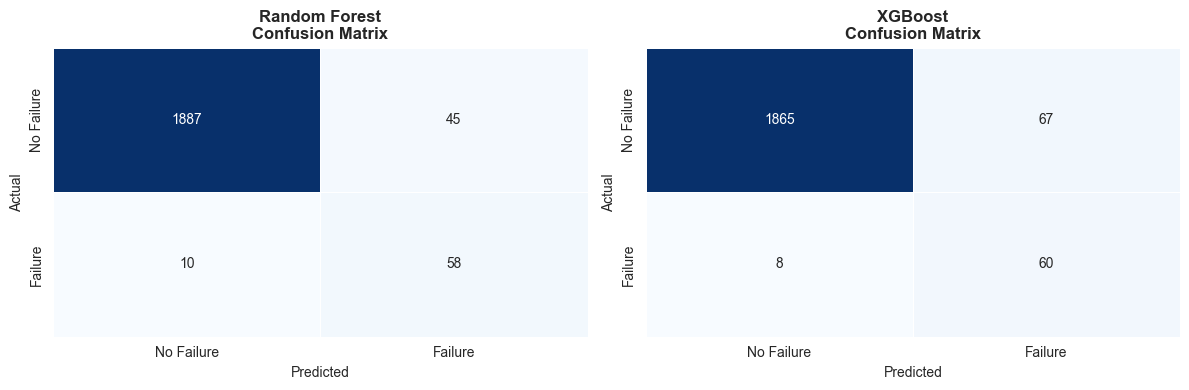

In [19]:
# ── 8.2 Confusion matrices ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
titles = ['Random Forest', 'XGBoost']
preds  = [rf_pred, xgb_pred]

for ax, title, pred in zip(axes, titles, preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Failure', 'Failure'],
                yticklabels=['No Failure', 'Failure'],
                linewidths=0.5, cbar=False)
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

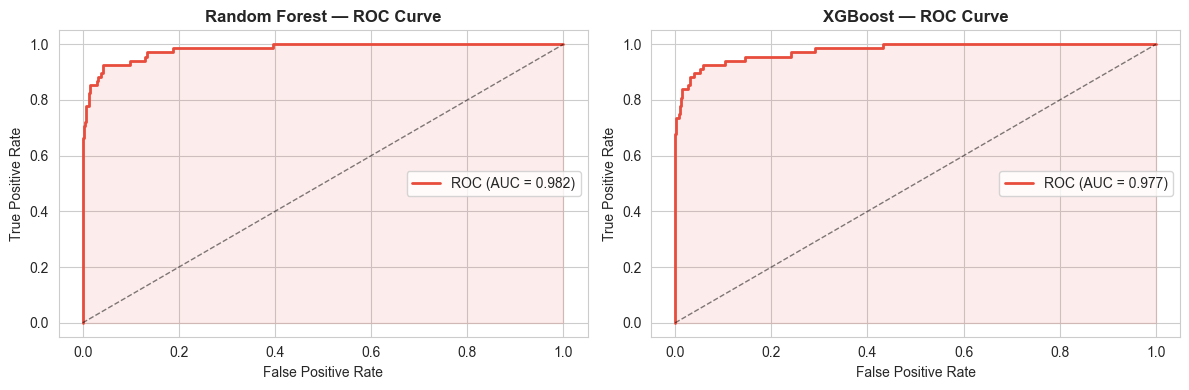

In [20]:
# ── 8.3 ROC curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, title, proba in zip(axes, titles, [rf_proba, xgb_proba]):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{title} — ROC Curve', fontsize=12, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

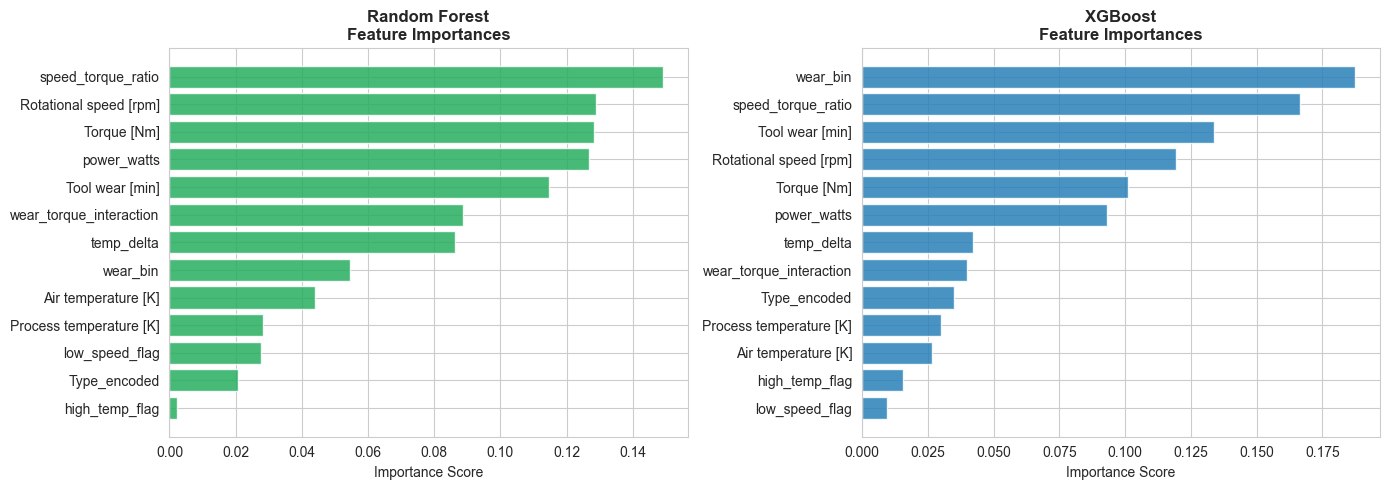

In [21]:
# ── 8.4 Feature importance comparison ────────────────────
rf_importances  = pd.Series(rf_model.feature_importances_,  index=FEATURE_COLS)
xgb_importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, imp, title, color in zip(
    axes,
    [rf_importances, xgb_importances],
    ['Random Forest', 'XGBoost'],
    ['#27ae60', '#2980b9']
):
    imp_sorted = imp.sort_values(ascending=True)
    ax.barh(imp_sorted.index, imp_sorted.values, color=color, alpha=0.85)
    ax.set_title(f'{title}\nFeature Importances', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [22]:
# ── 8.5 Cross-validation ──────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [('Random Forest', rf_model), ('XGBoost', xgb_model)]:
    cv_scores = cross_val_score(model, X_train_resampled, y_train_resampled,
                                cv=cv, scoring='roc_auc', n_jobs=1)  # avoid parallelism conflict with XGBoost threading
    print(f'{name} — CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Random Forest — CV ROC-AUC: 0.9993 ± 0.0002
XGBoost — CV ROC-AUC: 0.9997 ± 0.0002


## 🏆 Step 9: Select Best Model

In [23]:
rf_auc  = roc_auc_score(y_test, rf_proba)
xgb_auc = roc_auc_score(y_test, xgb_proba)

if xgb_auc >= rf_auc:
    best_model = xgb_model
    best_name  = 'XGBoost'
    best_auc   = xgb_auc
else:
    best_model = rf_model
    best_name  = 'RandomForest'
    best_auc   = rf_auc

print(f'🏆 Best model: {best_name} (ROC-AUC = {best_auc:.4f})')

🏆 Best model: RandomForest (ROC-AUC = 0.9815)


## 💾 Step 10: Save Artifacts for FastAPI

In [24]:
import os, json, joblib

# ── Use absolute path so files always save in the right place ──
BASE_DIR = os.path.dirname(os.path.abspath('ai4i_predictive_maintenance.ipynb'))
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'model', 'artifacts')
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# ── Delete old/duplicate pkl files first ──────────────────────
import shutil
bad_path = os.path.join(BASE_DIR, 'model\\artifacts')  # the duplicate
if os.path.exists(bad_path) and bad_path != ARTIFACTS_DIR:
    shutil.rmtree(bad_path)
    print(f'🗑️  Removed duplicate: {bad_path}')

# ── Save all artifacts ────────────────────────────────────────
joblib.dump(rf_model,     os.path.join(ARTIFACTS_DIR, 'rf_model.pkl'))
joblib.dump(xgb_model,    os.path.join(ARTIFACTS_DIR, 'xgb_model.pkl'))
joblib.dump(scaler,       os.path.join(ARTIFACTS_DIR, 'scaler.pkl'))
joblib.dump(le,           os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl'))
joblib.dump(FEATURE_COLS, os.path.join(ARTIFACTS_DIR, 'feature_cols.pkl'))

# ── Best model ────────────────────────────────────────────────
rf_auc_save  = roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])
xgb_auc_save = roc_auc_score(y_test, xgb_model.predict_proba(X_test_scaled)[:, 1])

if xgb_auc_save >= rf_auc_save:
    best_model_obj, best_model_name, best_auc_val = xgb_model, 'XGBoost', xgb_auc_save
else:
    best_model_obj, best_model_name, best_auc_val = rf_model, 'RandomForest', rf_auc_save

joblib.dump(best_model_obj, os.path.join(ARTIFACTS_DIR, 'model.pkl'))

# ── Metadata ──────────────────────────────────────────────────
import sklearn, xgboost
metadata = {
    'best_model':    best_model_name,
    'best_roc_auc':  round(best_auc_val, 4),
    'rf_roc_auc':    round(rf_auc_save, 4),
    'xgb_roc_auc':   round(xgb_auc_save, 4),
    'feature_cols':  FEATURE_COLS,
    'label_classes': list(le.classes_),
    'smote_used':    True,
    'sklearn_version': sklearn.__version__,   # track version to avoid mismatch
    'xgboost_version': xgboost.__version__
}
with open(os.path.join(ARTIFACTS_DIR, 'metadata.json'), 'w') as mf:
    json.dump(metadata, mf, indent=2)

# ── Verify ────────────────────────────────────────────────────
print(f'✅ Artifacts saved to: {ARTIFACTS_DIR}\n')
for fname in sorted(os.listdir(ARTIFACTS_DIR)):
    size = os.path.getsize(os.path.join(ARTIFACTS_DIR, fname))
    print(f'   📦 {fname:35s}  {size/1024:.1f} KB')

print(f'\n🏆 Best model  : {best_model_name}')
print(f'   sklearn     : {sklearn.__version__}')
print(f'   xgboost     : {xgboost.__version__}')

✅ Artifacts saved to: d:\Predictive_Maintenance\model\model\artifacts

   📦 feature_cols.pkl                     0.2 KB
   📦 label_encoder.pkl                    0.5 KB
   📦 metadata.json                        0.6 KB
   📦 model.pkl                            8490.5 KB
   📦 rf_model.pkl                         8490.5 KB
   📦 scaler.pkl                           1.4 KB
   📦 xgb_model.pkl                        779.4 KB

🏆 Best model  : RandomForest
   sklearn     : 1.5.2
   xgboost     : 2.1.1


## 🧪 Step 11: Test Prediction Pipeline (same as FastAPI will use)

In [25]:
def predict_failure(machine_type, air_temp, process_temp,
                    rotational_speed, torque, tool_wear,
                    model=best_model, scaler=scaler, le=le):
    """
    Replicates the FastAPI /predict endpoint logic.
    Returns: dict with prediction and probability.
    """
    # Encode type
    type_enc = le.transform([machine_type])[0]

    # Compute engineered features
    temp_delta              = process_temp - air_temp
    power_watts             = torque * (rotational_speed * 2 * np.pi / 60)
    wear_torque_interaction = tool_wear * torque
    speed_torque_ratio      = rotational_speed / (torque + 1e-6)
    wear_bin                = int(pd.cut([tool_wear], bins=[0, 60, 120, 180, 300], labels=[0, 1, 2, 3])[0])

    # Q90 of process temp from training data (precomputed)
    process_temp_q90 = df['Process temperature [K]'].quantile(0.90)
    speed_q10        = df['Rotational speed [rpm]'].quantile(0.10)
    high_temp_flag   = int(process_temp > process_temp_q90)
    low_speed_flag   = int(rotational_speed < speed_q10)

    features = np.array([[
        type_enc, air_temp, process_temp, rotational_speed,
        torque, tool_wear, temp_delta, power_watts,
        wear_torque_interaction, speed_torque_ratio,
        wear_bin, high_temp_flag, low_speed_flag
    ]])

    features_scaled = scaler.transform(features)
    prediction      = model.predict(features_scaled)[0]
    probability     = model.predict_proba(features_scaled)[0][1]

    risk = 'LOW' if probability < 0.2 else \
           'MEDIUM' if probability < 0.5 else \
           'HIGH' if probability < 0.75 else 'CRITICAL'

    return {
        'failure_predicted': bool(prediction),
        'failure_probability': round(float(probability), 4),
        'risk_level': risk,
        'message': '⚠️ Maintenance required!' if prediction else '✅ Machine operating normally.'
    }


# Test cases
print('--- Test 1: Normal operation ---')
print(predict_failure('M', 298.1, 308.6, 1551, 42.8, 10))

print('\n--- Test 2: High wear + high torque (likely failure) ---')
print(predict_failure('H', 302.0, 312.5, 1200, 68.0, 250))

print('\n--- Test 3: Low quality machine, high wear ---')
print(predict_failure('L', 300.5, 310.8, 1350, 55.0, 200))

--- Test 1: Normal operation ---
{'failure_predicted': False, 'failure_probability': 0.0, 'risk_level': 'LOW', 'message': '✅ Machine operating normally.'}

--- Test 2: High wear + high torque (likely failure) ---
{'failure_predicted': True, 'failure_probability': 0.84, 'risk_level': 'CRITICAL', 'message': '⚠️ Maintenance required!'}

--- Test 3: Low quality machine, high wear ---
{'failure_predicted': True, 'failure_probability': 0.8805, 'risk_level': 'CRITICAL', 'message': '⚠️ Maintenance required!'}


## ✅ Summary

In [26]:
print('='*55)
print('      AI4I 2020 PREDICTIVE MAINTENANCE — SUMMARY')
print('='*55)
print(f'  Dataset rows        : {len(df):,}')
print(f'  Failure rate        : {df["Machine failure"].mean()*100:.1f}%')
print(f'  Features used       : {len(FEATURE_COLS)} (incl. 7 engineered)')
print(f'  Imbalance handled   : SMOTE oversampling')
print(f'  Random Forest AUC   : {rf_auc:.4f}')
print(f'  XGBoost AUC         : {xgb_auc:.4f}')
print(f'  Best model          : {best_name}')
print(f'  Artifacts saved to  : model/artifacts/')
print('='*55)
print('  🚀 Ready to plug into FastAPI!')

      AI4I 2020 PREDICTIVE MAINTENANCE — SUMMARY
  Dataset rows        : 10,000
  Failure rate        : 3.4%
  Features used       : 13 (incl. 7 engineered)
  Imbalance handled   : SMOTE oversampling
  Random Forest AUC   : 0.9815
  XGBoost AUC         : 0.9774
  Best model          : RandomForest
  Artifacts saved to  : model/artifacts/
  🚀 Ready to plug into FastAPI!
